# Téléchargement du dataset Kaggle
on utilise  le célèbre dataset Credit Card Fraud Detection de Kaggle (284 807 transactions, 492 fraudes).

In [4]:
!pip install kaggle
from google.colab import files
files.upload()
!kaggle datasets download -d mlg-ulb/creditcardfraud
!unzip creditcardfraud.zip

Saving creditcard.csv.zip to creditcard.csv.zip
Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
100% 66.0M/66.0M [00:00<00:00, 168MB/s]

Archive:  creditcardfraud.zip
  inflating: creditcard.csv          


# EDA
Analyse la distribution des classes, les statistiques descriptives, et les corrélations entre variables.

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [6]:
df = pd.read_csv('creditcard.csv')
print(f"Nombre de colonnes : {len(df.columns)}")
print(f"Nombre de lignes : {len(df)}")
print(df['Class'].value_counts())
df.describe()



Nombre de colonnes : 31
Nombre de lignes : 284807
Class
0    284315
1       492
Name: count, dtype: int64


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


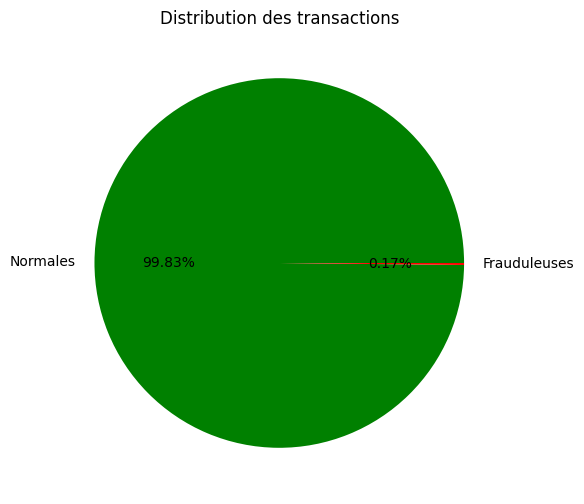

In [7]:

# Pie chart
plt.figure(figsize = (8,6))
plt.pie(df['Class'].value_counts().values, labels = ['Normales', 'Frauduleuses'],colors = ['green','red'],autopct= '%1.2f%%')
plt.title('Distribution des transactions')
plt.show()


# Prétraitement des données
**1. normalisation des feutures**


In [8]:
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split



In [9]:
scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df[['Amount']])
df['Time'] = scaler.fit_transform(df[['Time']])

**2. train/test split avec stratification**


In [10]:
x = df.drop('Class', axis = 1)
y = df['Class']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42, stratify = y)


# Modélisation de Entrainement
**1. logistic regression**

Dans la réalité bancaire, rater une fraude coûte plus cher que bloquer à tort une transaction. Donc le Recall est la métrique prioritaire.


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import f1_score
import numpy as np


In [13]:
#Modèle Logistic Regression
model = LogisticRegression(max_iter=1000)

#Entraînement
model.fit(x_train, y_train)

#Prédictions
y_pred = model.predict_proba(x_test)[:, 1]
y_pred_custom = (y_pred > 0.15).astype(int)

#Évaluation
print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.74      0.77      0.75        98

    accuracy                           1.00     56962
   macro avg       0.87      0.88      0.87     56962
weighted avg       1.00      1.00      1.00     56962



In [14]:
y_proba = model.predict_proba(x_test)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.05)
best_thresh = 0
best_score = 0

for t in thresholds:
    y_pred = (y_proba > t).astype(int)
    score = f1_score(y_test, y_pred)

    if score > best_score:
        best_score = score
        best_thresh = t

print("Meilleur seuil :", best_thresh)
print("Meilleur F1-score :", best_score)

Meilleur seuil : 0.15000000000000002
Meilleur F1-score : 0.75


Un seuil de 0.15 a été retenu afin de privilégier le rappel tout en maintenant une précision acceptable. Cette approche permet de détecter une proportion importante de fraudes sans générer un nombre excessif de faux positifs.

**2. Random Forest**

In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report


In [39]:
model1 = RandomForestClassifier(n_estimators=50,max_depth = 10,n_jobs = -1, random_state=42)
model1.fit(x_train, y_train)
y_pred1 = model1.predict(x_test)
print(classification_report(y_test, y_pred1))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.82      0.87        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962



**3.XGBoost**


In [18]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

In [40]:
model2 = XGBClassifier(n_estimators=200,max_depth = 5,n_jobs = -1, random_state=42)

model2.fit(x_train, y_train)

y_proba = model2.predict_proba(x_test)[:,1]
y_pred2 = (y_proba > 0.17).astype(int)
print(classification_report(y_test, y_pred2))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.78      0.77      0.77        98

    accuracy                           1.00     56962
   macro avg       0.89      0.88      0.89     56962
weighted avg       1.00      1.00      1.00     56962



In [26]:
import numpy as np
from sklearn.metrics import f1_score

def find_best_threshold(y_true, y_proba):
    thresholds = np.arange(0.01, 1.0, 0.01)
    best_thresh = 0
    best_score = 0

    for t in thresholds:
        y_pred = (y_proba > t).astype(int)
        score = f1_score(y_true, y_pred)

        if score > best_score:
            best_score = score
            best_thresh = t

    return best_thresh, best_score

y_proba = model.predict_proba(x_test)[:,1]

best_t, best_f1 = find_best_threshold(y_test, y_proba)

print("Meilleur seuil :", best_t)
print("F1-score :", best_f1)

Meilleur seuil : 0.17
F1-score : 0.7537688442211056


Le seuil de décision a été ajusté à 0.17 afin d’obtenir un équilibre optimal entre précision et rappel, permettant une détection efficace des fraudes tout en limitant les faux positifs

**4. KNN**


In [33]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

In [41]:
# Modèle KNN
model3 = KNeighborsClassifier(n_neighbors=5)

# Entraînement
model3.fit(x_train, y_train)

# Prédictions
y_pred3 = model3.predict(x_test)

# Évaluation
print(classification_report(y_test, y_pred3))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.92      0.81      0.86        98

    accuracy                           1.00     56962
   macro avg       0.96      0.90      0.93     56962
weighted avg       1.00      1.00      1.00     56962



# Évaluation et comparaison des modèles

In [37]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

In [42]:

# Fonction pour calculer les métriques
def evaluate_model(name, y_true, y_pred):
    return {
        "Model": name,
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred)
    }

# Stocker les résultats
results = []

results.append(evaluate_model("Logistic Regression", y_test, y_pred_custom))
results.append(evaluate_model("Random Forest", y_test, y_pred1))
results.append(evaluate_model("XGBoost", y_test, y_pred2))
results.append(evaluate_model("KNN", y_test, y_pred3))

# Créer tableau
df_results = pd.DataFrame(results)

# Trier par F1-score
df_results = df_results.sort_values(by="F1-score", ascending=False)

print(df_results)

                 Model  Precision    Recall  F1-score
1        Random Forest   0.941176  0.816327  0.874317
3                  KNN   0.918605  0.806122  0.858696
2              XGBoost   0.781250  0.765306  0.773196
0  Logistic Regression   0.735294  0.765306  0.750000


🎯 Analyse
* Random Forest → meilleur F1-score
* XGBoost → bon mais moins précis
* KNN → bon compromis
* Logistic → baseline

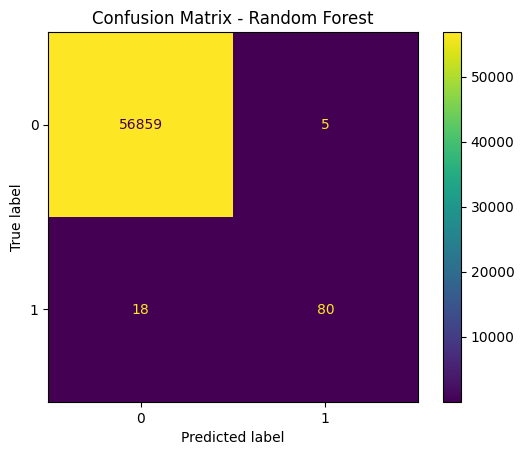

In [47]:

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred1)
plt.title("Confusion Matrix - Random Forest")
plt.show()

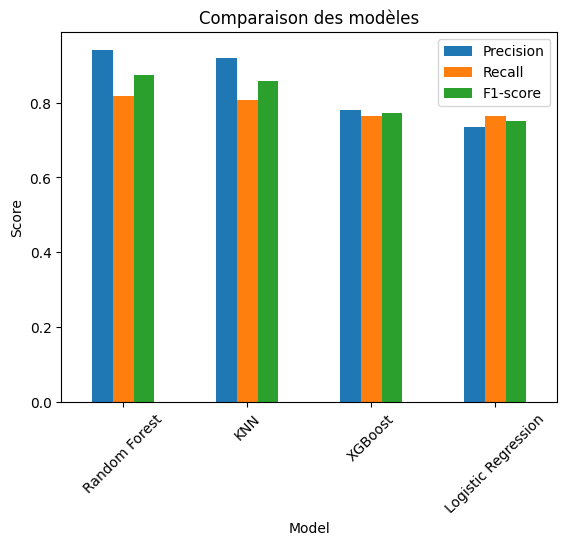

In [46]:
import matplotlib.pyplot as plt

df_results.set_index("Model")[["Precision","Recall","F1-score"]].plot(kind="bar")
plt.title("Comparaison des modèles")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()

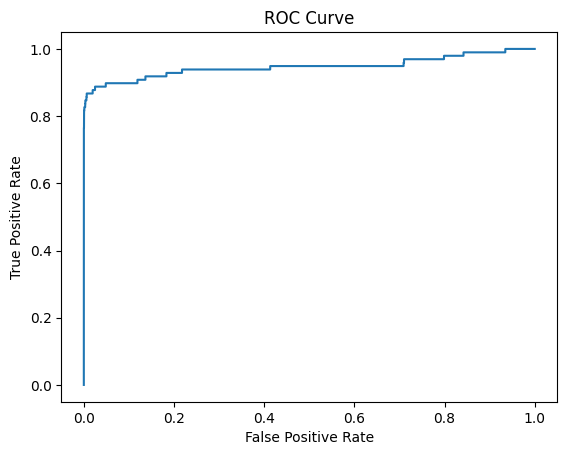

In [48]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

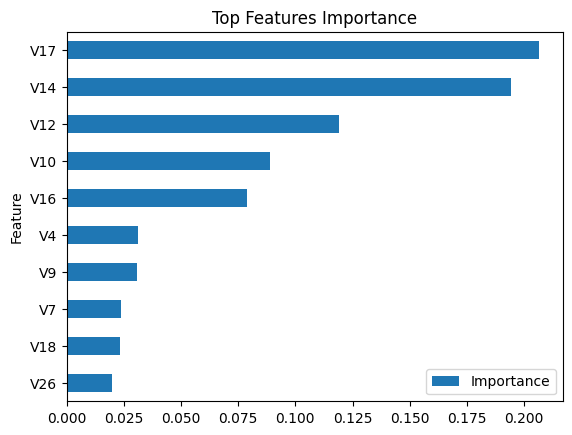

In [49]:
import pandas as pd

importances = model1.feature_importances_
features = x_train.columns

df_imp = pd.DataFrame({"Feature": features, "Importance": importances})
df_imp = df_imp.sort_values(by="Importance", ascending=False).head(10)

df_imp.plot(kind="barh", x="Feature", y="Importance")
plt.title("Top Features Importance")
plt.gca().invert_yaxis()
plt.show()